# Clasificacion de Estado Mental con BiLSTM
### Dataset: EEG Brainwave — Mental State (Kaggle)
### Estados: 0 = Neutral | 1 = Relaxed | 2 = Concentrating

## Importaciones

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
from tqdm import tqdm

torch.manual_seed(42)
np.random.seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Dispositivo:', device)

Dispositivo: cpu


## Carga del Dataset

In [2]:
RUTA = r'C:\Users\Usuario\Desktop\INTELIG. ARTIF. 2\IA_2\INTELIGENCIA ATIFICIAL II\Extra_LAB_ 03\Dataset\mental-state.csv'

df = pd.read_csv(RUTA)
df = df.dropna().reset_index(drop=True)

print(f'Shape   : {df.shape}')
print(f'Clases  : {sorted(df["Label"].unique())}')
print(f'\nDistribucion de clases:')
print(df['Label'].value_counts().sort_index())
df.head(3)

Shape   : (2479, 989)
Clases  : [np.float64(0.0), np.float64(1.0), np.float64(2.0)]

Distribucion de clases:
Label
0.0    819
1.0    830
2.0    830
Name: count, dtype: int64


,lag1_mean_0,lag1_mean_1,lag1_mean_2,lag1_mean_3,lag1_mean_d_h2h1_0,lag1_mean_d_h2h1_1,lag1_mean_d_h2h1_2,lag1_mean_d_h2h1_3,lag1_mean_q1_0,lag1_mean_q1_1,...,freq_669_3,freq_679_3,freq_689_3,freq_699_3,freq_709_3,freq_720_3,freq_730_3,freq_740_3,freq_750_3,Label
0,25.781648,33.836367,-92.769629,19.187957,-1.542262,0.197462,-119.561133,2.032654,21.596272,33.965587,...,0.000230,0.000351,0.000547,0.000381,0.000350,0.000453,0.000442,0.000325,0.000209,2.0
1,29.357891,26.792566,417.203910,19.472121,-38.797263,-16.897194,-29.368531,-9.055370,44.647424,40.893307,...,0.001671,0.000740,0.001122,0.000521,0.000624,0.000439,0.001249,0.000727,0.000801,2.0
2,28.451926,31.076434,72.231301,14.245938,-13.225057,-0.614138,-28.331698,-8.858742,31.450289,30.692883,...,0.000748,0.000569,0.000327,0.000197,0.000833,0.000909,0.000699,0.001165,0.000616,2.0


## Preprocesamiento

Este dataset ya tiene las features extraidas (medias, FFT, frecuencias, covarianzas, etc.) de los 4 canales EEG. Cada fila es una ventana temporal ya procesada.

Para alimentar el BiLSTM necesitamos una secuencia. Reorganizamos las 988 features en grupos de 4 (un valor por canal EEG), lo que da 247 timesteps por muestra. Asi el BiLSTM procesa la evolucion de los 4 canales a lo largo de los distintos tipos de features extraidas.

In [4]:
LABEL_COL  = 'Label'
N_CHANNELS = 4
N_CLASSES  = 3

feature_cols = [c for c in df.columns if c != LABEL_COL]
n_features   = len(feature_cols)
n_timesteps  = n_features // N_CHANNELS

print(f'Total features  : {n_features}')
print(f'Timesteps BiLSTM: {n_timesteps}')
print(f'Canales         : {N_CHANNELS}')

X_raw = df[feature_cols].values.astype(np.float32)
y_raw = df[LABEL_COL].values.astype(np.int64)

scaler = StandardScaler()
X_norm = scaler.fit_transform(X_raw).astype(np.float32)

X_seq = X_norm[:, :n_timesteps * N_CHANNELS].reshape(-1, n_timesteps, N_CHANNELS)

print(f'\nShape final X   : {X_seq.shape}')
print(f'Shape final y   : {y_raw.shape}')

Total features  : 988
Timesteps BiLSTM: 247
Canales         : 4

Shape final X   : (2479, 247, 4)
Shape final y   : (2479,)


## Split Train / Val / Test

In [5]:
n_total = len(X_seq)
n_train = int(n_total * 0.70)
n_valid = int(n_total * 0.15)

idx = np.random.permutation(n_total)
train_idx = idx[:n_train]
valid_idx = idx[n_train:n_train+n_valid]
test_idx  = idx[n_train+n_valid:]

X_train, y_train = X_seq[train_idx], y_raw[train_idx]
X_valid, y_valid = X_seq[valid_idx], y_raw[valid_idx]
X_test,  y_test  = X_seq[test_idx],  y_raw[test_idx]

print(f'Train : {X_train.shape}')
print(f'Valid : {X_valid.shape}')
print(f'Test  : {X_test.shape}')

Train : (1735, 247, 4)
Valid : (371, 247, 4)
Test  : (373, 247, 4)


## Dataset y DataLoader

In [6]:
class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, ix):
        return self.X[ix], self.y[ix]

dataset = {
    'train': EEGDataset(X_train, y_train),
    'eval' : EEGDataset(X_valid, y_valid),
    'test' : EEGDataset(X_test,  y_test)
}

dataloader = {
    'train': DataLoader(dataset['train'], shuffle=True,  batch_size=64),
    'eval' : DataLoader(dataset['eval'],  shuffle=False, batch_size=64),
    'test' : DataLoader(dataset['test'],  shuffle=False, batch_size=64)
}

## Modelo BiLSTM

Un LSTM Bidireccional procesa la secuencia de features EEG en dos direcciones: de inicio a fin y de fin a inicio. Esto permite capturar dependencias tanto tempranas como tardias en la representacion de la senal cerebral, lo que lo hace superior a un LSTM unidireccional para clasificacion de patrones complejos.

In [7]:
class BiLSTM(nn.Module):
    def __init__(self, n_features=4, hidden_size=128, n_layers=2, n_classes=3, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size    = n_features,
            hidden_size   = hidden_size,
            num_layers    = n_layers,
            batch_first   = True,
            bidirectional = True,
            dropout       = dropout if n_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size * 2, n_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        out    = self.dropout(out[:, -1, :])
        return self.fc(out)

model = BiLSTM(n_features=N_CHANNELS, n_classes=N_CLASSES).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nParametros entrenables: {total_params:,}')

BiLSTM(
  (lstm): LSTM(4, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=3, bias=True)
)

Parametros entrenables: 533,251


## Entrenamiento con Early Stopping

In [8]:
EPOCHS   = 100
LR       = 1e-3
PATIENCE = 10

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

best_val_loss     = float('inf')
epochs_sin_mejora = 0
best_weights      = None
history           = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in tqdm(range(1, EPOCHS + 1), desc='Entrenando'):

    model.train()
    train_loss, train_correct = 0.0, 0
    for X_batch, y_batch in dataloader['train']:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        train_loss    += loss.item() * len(X_batch)
        train_correct += (logits.argmax(1) == y_batch).sum().item()
    train_loss /= len(dataset['train'])
    train_acc   = train_correct / len(dataset['train'])

    model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for X_batch, y_batch in dataloader['eval']:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits      = model(X_batch)
            val_loss   += criterion(logits, y_batch).item() * len(X_batch)
            val_correct += (logits.argmax(1) == y_batch).sum().item()
    val_loss /= len(dataset['eval'])
    val_acc   = val_correct / len(dataset['eval'])

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    scheduler.step(val_loss)

    if epoch % 10 == 0 or epoch == 1:
        lr_actual = optimizer.param_groups[0]['lr']
        print(f'Epoca {epoch:>3} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | LR: {lr_actual:.6f}')

    if val_loss < best_val_loss:
        best_val_loss     = val_loss
        best_weights      = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_sin_mejora = 0
    else:
        epochs_sin_mejora += 1
        if epochs_sin_mejora >= PATIENCE:
            print(f'Early stopping en epoca {epoch} | Mejor Val Loss: {best_val_loss:.4f}')
            break

model.load_state_dict(best_weights)
print(f'Entrenamiento finalizado | Mejor Val Loss: {best_val_loss:.4f}')

Entrenando:   1%|          | 1/100 [01:00<1:39:42, 60.43s/it]

Epoca   1 | Train Loss: 0.8616 Acc: 0.5585 | Val Loss: 0.7631 Acc: 0.6226 | LR: 0.001000


Entrenando:  10%|█         | 10/100 [04:06<27:04, 18.05s/it] 

Epoca  10 | Train Loss: 0.5428 Acc: 0.7118 | Val Loss: 0.5773 Acc: 0.7170 | LR: 0.001000


Entrenando:  20%|██        | 20/100 [07:04<21:02, 15.78s/it]

...

Epoca  60 | Train Loss: 0.2247 Acc: 0.9078 | Val Loss: 0.3494 Acc: 0.8679 | LR: 0.000500


Entrenando:  70%|███████   | 70/100 [23:27<07:23, 14.78s/it]

Epoca  70 | Train Loss: 0.1800 Acc: 0.9285 | Val Loss: 0.2906 Acc: 0.9003 | LR: 0.000500


Entrenando:  74%|███████▍  | 74/100 [24:39<08:39, 19.99s/it]

Early stopping en epoca 75 | Mejor Val Loss: 0.2680
Entrenamiento finalizado | Mejor Val Loss: 0.2680


## Curvas de Entrenamiento

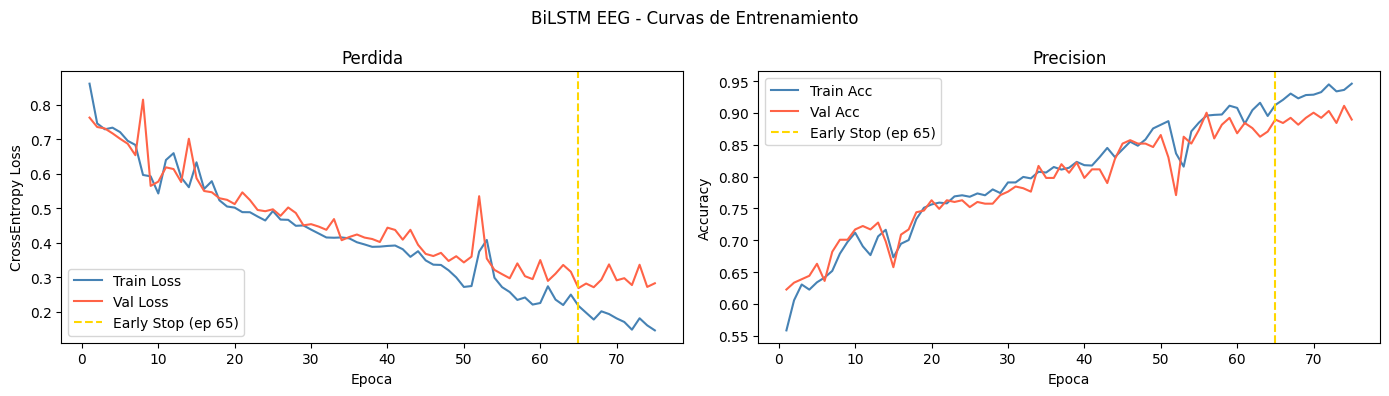

In [9]:
epochs_range = range(1, len(history['train_loss']) + 1)
mejor_epoca  = history['val_loss'].index(min(history['val_loss'])) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epochs_range, history['train_loss'], color='steelblue', label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'],   color='tomato',    label='Val Loss')
axes[0].axvline(x=mejor_epoca, color='gold', linestyle='--', label=f'Early Stop (ep {mejor_epoca})')
axes[0].set_title('Perdida')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('CrossEntropy Loss')
axes[0].legend()

axes[1].plot(epochs_range, history['train_acc'], color='steelblue', label='Train Acc')
axes[1].plot(epochs_range, history['val_acc'],   color='tomato',    label='Val Acc')
axes[1].axvline(x=mejor_epoca, color='gold', linestyle='--', label=f'Early Stop (ep {mejor_epoca})')
axes[1].set_title('Precision')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('BiLSTM EEG - Curvas de Entrenamiento')
plt.tight_layout()
plt.show()

## Evaluacion sobre el Test Set

In [10]:
NOMBRES_CLASES = ['Neutral', 'Relaxed', 'Concentrating']

model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for X_batch, y_batch in dataloader['test']:
        logits = model(X_batch.to(device))
        preds  = logits.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(y_batch.numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

test_acc = (all_preds == all_true).mean()
print(f'Accuracy en Test Set: {test_acc:.4f} ({test_acc*100:.2f}%)\n')
print(classification_report(all_true, all_preds, target_names=NOMBRES_CLASES))

Accuracy en Test Set: 0.8633 (86.33%)

               precision    recall  f1-score   support

      Neutral       0.82      0.80      0.81       116
      Relaxed       0.81      0.83      0.82       139
Concentrating       0.98      0.96      0.97       118

     accuracy                           0.86       373
    macro avg       0.87      0.86      0.87       373
 weighted avg       0.86      0.86      0.86       373



## Matriz de Confusion

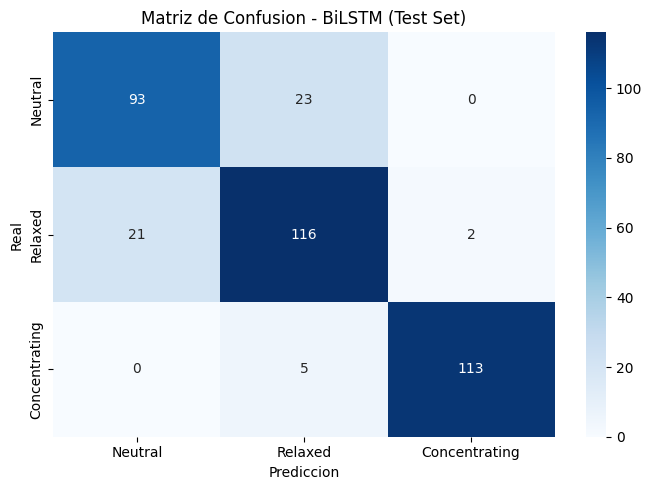

In [11]:
cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot       = True,
    fmt         = 'd',
    cmap        = 'Blues',
    xticklabels = NOMBRES_CLASES,
    yticklabels = NOMBRES_CLASES
)
plt.title('Matriz de Confusion - BiLSTM (Test Set)')
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

## Distribucion de Predicciones vs Reales

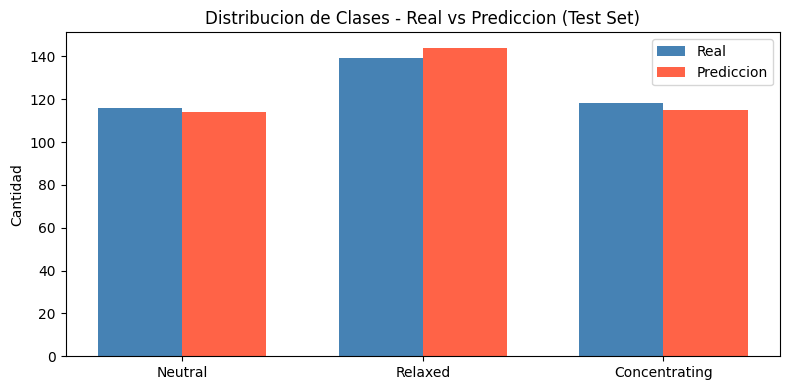

In [12]:
reales_cnt = [np.sum(all_true  == i) for i in range(N_CLASSES)]
preds_cnt  = [np.sum(all_preds == i) for i in range(N_CLASSES)]

x     = np.arange(N_CLASSES)
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, reales_cnt, width, label='Real',       color='steelblue')
ax.bar(x + width/2, preds_cnt,  width, label='Prediccion', color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(NOMBRES_CLASES)
ax.set_title('Distribucion de Clases - Real vs Prediccion (Test Set)')
ax.set_ylabel('Cantidad')
ax.legend()
plt.tight_layout()
plt.show()

## Resumen Final

In [13]:
precision = precision_score(all_true, all_preds, average='weighted')
recall    = recall_score(all_true,    all_preds, average='weighted')
f1        = f1_score(all_true,        all_preds, average='weighted')

print('=' * 55)
print('      RESUMEN FINAL - BiLSTM EEG MENTAL STATE')
print('=' * 55)

print(f'\nDATASET')
print(f'  Total muestras   : {len(df)}')
print(f'  Total features   : {n_features}')
print(f'  Clases           : {NOMBRES_CLASES}')

print(f'\nCONFIGURACION DEL MODELO')
print(f'  Modelo           : BiLSTM Bidireccional')
print(f'  Timesteps        : {n_timesteps}')
print(f'  Canales (entrada): {N_CHANNELS}')
print(f'  Hidden size      : 128  |  Capas LSTM: 2')
print(f'  Dropout          : 0.3')
print(f'  Parametros       : {total_params:,}')
print(f'  Optimizer        : Adam  |  LR: {LR}')
print(f'  Early Stopping   : patience={PATIENCE}')

print(f'\nENTRENAMIENTO')
print(f'  Epocas ejecutadas: {len(history["train_loss"])}')
print(f'  Mejor epoca      : {mejor_epoca}')
print(f'  Mejor Val Loss   : {best_val_loss:.4f}')
print(f'  Mejor Val Acc    : {max(history["val_acc"]):.4f}')

print(f'\nMETRICAS TEST SET')
print(f'  Accuracy         : {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'  Precision (w)    : {precision:.4f}')
print(f'  Recall (w)       : {recall:.4f}')
print(f'  F1-Score (w)     : {f1:.4f}')

print('\n' + '=' * 55)
print('Copia este bloque y mandamelo para el veredicto.')
print('=' * 55)

      RESUMEN FINAL - BiLSTM EEG MENTAL STATE

DATASET
  Total muestras   : 2479
  Total features   : 988
  Clases           : ['Neutral', 'Relaxed', 'Concentrating']

CONFIGURACION DEL MODELO
  Modelo           : BiLSTM Bidireccional
  Timesteps        : 247
  Canales (entrada): 4
  Hidden size      : 128  |  Capas LSTM: 2
  Dropout          : 0.3
  Parametros       : 533,251
  Optimizer        : Adam  |  LR: 0.001
  Early Stopping   : patience=10

ENTRENAMIENTO
  Epocas ejecutadas: 75
  Mejor epoca      : 65
  Mejor Val Loss   : 0.2680
  Mejor Val Acc    : 0.9111

METRICAS TEST SET
  Accuracy         : 0.8633 (86.33%)
  Precision (w)    : 0.8647
  Recall (w)       : 0.8633
  F1-Score (w)     : 0.8638

Copia este bloque y mandamelo para el veredicto.
